# 05 회귀

### 01. 회귀 소개

회귀 분석: 데이터 값이 평균과 같은 일정한 값으로 돌아가려는 경향을 이용함  
독립변수-Feature, 종속변수-결정 값, 회귀 계수-회귀 예측에서 최적의 회귀 계수를 찾아야 함  
독립변수 개수| 회귀 계수의 결합  
-|-
1개: 단일 회귀|선형: 선형 회귀
여러 개: 다중 회귀|비선형: 비선형 회귀

지도학습
1. 분류의 예측값: 카테고리 값(이산형 클래스 값)
2. 화귀의 예측값: 연속형 숫자값

선형회귀
Regularization: 일반적인 선형 회귀의 과적합 문제를 해결하기 위해서 회계 계수에 페널티 값 적용
1. 일반 선형 회귀: Regularization 적용 X
2. 릿지(Ridge): 선형 회귀 +L2 Regularizaion, L2 regularizaion은 상대적으로 큰 회귀 계수 값의 예측 영향도를 갑소하기 위해서 회귀 계수ㄱ밧을 더 작게 만드는 규제 모델
3. 라쏘(Lasso):선형 회귀 +L1 Regularizaion, 예측 영향력이 작은 피처의 회귀 계수를 0으로 만들어 회귀 예측 시 피처가 선택되지 않도록 함
4. 엘라스틱넷(ElasticNet): L2, L1 Regularization 결합, 주로 피처가 많은 데이터 세트에 적용
5. 로지스킥 회귀: 회귀라는 이름이 분ㅌ어 있지만, 사실은 분류에 사용되는 선형 모델

### 02 단순 선형 회귀를 통한 회귀 이해

$\hat{Y}=w_0 + W_1*X$+오류값  
오류값:잔차  
전체 데이터의 찬차의 합이 최소가 되는 모델을 만들자!  
오류합 계산시  
1. Mean Absolute Error: 절댓값
2. Rss(Residual Sum of Square): 오류 값의 제곱을 구해서  
   $Error^2=RSS$

##### RSS
w가 중심 변수!(독립변수와 종속변수는 모두 상수로 간주  
$RSS(w_0,W_1) =1/N\sum_{i=1}^{n} (y_i - (w_0+w_1*x_i))^2$  
RSS 비용함수(Loss Function), 손실함수

### 03 비용 최소화하기 - 경사 하강법(Gradient Desent)소개

'점진적으로' 반복적인 계산을 통해 W파라미터 값을 업데이트하면서 오류 값이 최소가 되는 W파라미터를 구하는 방식
RSS 경사하강법
1. $w_1,w_0$를 임의의 값으로 설정하고 첫 비용 함수의 값을 계산
2. $w_1$을 $w_1+\alpha*2/N\sum_{i=1}^{n}x_i*(실제값_i-예측값_i)$, $w_0$을 $w_0+\alpha*2/N\sum_{i=1}^{n}(실제값_i-예측값_i)$으로 업데이트한 후 다시 비용 함수의 값을 계산합니다.
3. 비용 함수가 감소하는 방향성으로 주어진 횟수만큼 2를 반복하면서 $w_1$과 $w_0$를계속 업데이트

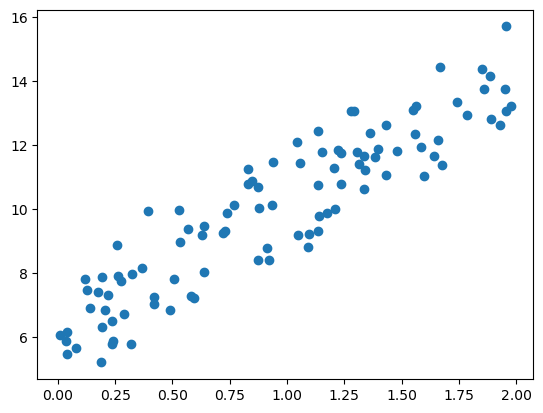

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

np.random.seed(0)
# y=4X+6을 근사(w1=4, w0=6). 임의의 값은 노이즈를 위해 만듦.
X=2*np.random.rand(100,1) #균등분포(uniform distribution)으로 (0~1사이)*2 수를 100행 1열로 생성
y=6+4*X+np.random.randn(100,1)

#X,y 데이터 세트 산점도로 시각화
plt.scatter(X,y)
plt.show()

In [3]:
#비용함수
def get_cost(y,y_pred):
    N=len(y)
    cost=np.sum(np.square(y-y_pred))/N
    return cost

In [4]:
#w1과 w0을 업데이트할 w1_update,w0_update를 반환
def get_weight_updates(w1,w0,X,y,learning_rate=0.01):
    N=len(y)
    #먼저 w1_update, w0_update를 각각 w1, w0의 shape와 동일한 크기를 가진 0 값으로 초기화
    w1_update=np.zeros_like(w1)
    w0_update=np.zeros_like(w0)
    #예측 배열 계산하고 예측과 실제 값의 차이 계산
    y_pred=np.dot(X,w1.T)+w0
    diff=y-y_pred

    #w0_update를 dot 행렬 연산으로 구하기 위해 모두 1값을 가진 행렬 생성 
    w0_factors=np.ones((N,1))
    #w1과 w0을 업데이트할 w1_update와 w0_update 계산
    w1_update=-(2/N)*learning_rate*(np.dot(X.T,diff))
    w0_update=-(2/N)*learning_rate*(np.dot(w0_factors.T,diff))

    return w1_update,w0_update

In [7]:
#입력 인자 iters로 주어진 횟수만큼 반복적으로 w1과 w0을 업데이트 적용함.
def gradient_descent_steps(X,y,iters=1000):
    #w0과 w1을 모두 0으로 초기화.
    w0=np.zeros((1,1))
    w1=np.zeros((1,1))

    #인자로 주어진 iters만큼 반복적으로 get_weight_updates() 호출해 w1,w0 업데이트 수행.
    for ind in range(iters):
        w1_update,w0_update=get_weight_updates(w1,w0,X,y,learning_rate=0.01)
        w1=w1-w1_update
        w0=w0-w0_update

    return w1,w0

In [10]:
def get_cost(y,y_pred):
    N=len(y)
    cost=np.sum(np.square(y-y_pred))/N
    return cost

w1,w0=gradient_descent_steps(X,y,iters=1000)
print("w1:{0:.3f} w0:{1:.3f}".format(w1[0,0],w0[0,0]))
y_pred=w1[0,0]*X+w0
print('Gradient Descent Total Cost:{0:.4f}'.format(get_cost(y,y_pred)))

w1:4.022 w0:6.162
Gradient Descent Total Cost:0.9935


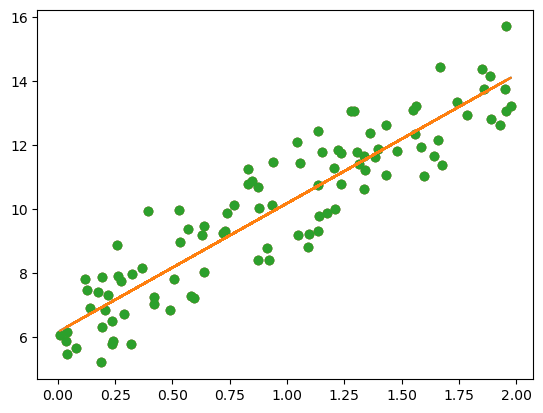

In [13]:
plt.scatter(X,y)
plt.plot(X,y_pred)
plt.show()

경사 하강법은 시간이 오래걸리므로 (미니배치)확률적 경사 하강법(stochastic_gradient_descent_steps())사용

In [14]:
def stochastic_gradient_descent_steps(X, y, batch_size=10, iters=1000):
    w0=np.zeros((1,1))
    w1=np.zeros((1,1))
    
    for ind in range(iters):
        np.random.seed(ind)
        #전체 X, y 데이터에서 랜덤하게 batch_size만큼 데이터 추출하여 sample_X, sample_y로 저장
        stochastic_random_index=np.random.permutation(X.shape[0])
        sample_X=X[stochastic_random_index[0:batch_size]]
        sample_y=y[stochastic_random_index[0:batch_size]]
        #랜덤하게 batch_size만큼 추출된 데이터 기반으로 w1_update, w0_update 계산 후 업데이트
        w1_update, w0_update = get_weight_updates(w1, w0, sample_X, sample_y, learning_rate=0.01)
        w1=w1 - w1_update
        w0=w0 - w0_update
    
    return w1, w0

In [16]:
w1, w0=stochastic_gradient_descent_steps(X, y, iters=1000)
print("w1:",round(w1[0,0],3),"w0:",round(w0[0,0],3))
y_pred=w1[0,0]*X+w0
print('Stochastic Gradient Descent Total Cost:{0:.4f}'.format(get_cost(y, y_pred)))
  

w1: 4.028 w0: 6.156
Stochastic Gradient Descent Total Cost:0.9937


### 04 사이킷런 LinearRegression을 이용한 보스턴 주택 가격 예측
#### LinearRegression 클래스 - Ordinary Least Squares  
OLS는 입력 피처의 독립성의 많은 영향을 받음, 피처 간의 상관관계가 매우 높은 경우 분산이 매우 커져서 오류에 민감해짐--> 다중공선성(multi-collinearity)문제  
중요한 피처만 남기거나 PCA 차원 축소로 해결
class sklearn.linear_model.LinearRegression(fit_intercept=True, normalize=False, copy_X=True, n_jobs=1)  
fit_intercept: 디폴트 True ,False시 intercept사용되지 않고 0  

#### 회귀 평가 지표
1. MAE: 실제값, 예측값 차이를 절댓값으로 변환
2. MSE: 실제값, 예측값 차이를 제곱해 평균
3. RMSE: 실제값, 예측값 차이를 제곱해 평균하고 루트
4. R^2: 예측값 분산/실제값 분산, 1에 가까울수록 예측 정확도 높음


Scoring 함수에서 score 값이 클수록 좋은 평가 결과로 자동 평가하기 때문에  
Scoring 함수 적용시 - 붙여줘야 함

#### LinearRegression을 이용해 보스턴 주택 가격 회귀 구현
!! sklean에서 보스턴 주택 사라짐

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.datasets import load_boston
import warnings
warnings.filterwarnings('ignore')  #사이킷런 1.2 부터는 보스턴 주택가격 데이터가 없어진다는 warning 메시지 출력 제거
%matplotlib inline

# boston 데이타셋 로드
boston=load_boston()

# boston 데이타셋 DataFrame 변환 
bostonDF=pd.DataFrame(boston.data , columns=boston.feature_names)

# boston dataset의 target array는 주택 가격임. 이를 PRICE 컬럼으로 DataFrame에 추가함. 
bostonDF['PRICE']=boston.target
print('Boston 데이타셋 크기 :',bostonDF.shape)
bostonDF.head()

ImportError: 
`load_boston` has been removed from scikit-learn since version 1.2.

The Boston housing prices dataset has an ethical problem: as
investigated in [1], the authors of this dataset engineered a
non-invertible variable "B" assuming that racial self-segregation had a
positive impact on house prices [2]. Furthermore the goal of the
research that led to the creation of this dataset was to study the
impact of air quality but it did not give adequate demonstration of the
validity of this assumption.

The scikit-learn maintainers therefore strongly discourage the use of
this dataset unless the purpose of the code is to study and educate
about ethical issues in data science and machine learning.

In this special case, you can fetch the dataset from the original
source::

    import pandas as pd
    import numpy as np

    data_url = "http://lib.stat.cmu.edu/datasets/boston"
    raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
    data = np.hstack([raw_df.values[:

In [18]:
# 'RM','ZN','INDUS','NOX','AGE','PTRATIO','LSTAT','RAD'의 총 8개의 칼럼에 대해 PRICE가 어떻게 변하는지 확인
# 2개의 행과 4개의 열을 가진 subplots를 이용. axs는 4x2개의 ax를 가짐.
fig, axs = plt.subplots(figsize=(16,8) , ncols=4 , nrows=2)
lm_features = ['RM','ZN','INDUS','NOX','AGE','PTRATIO','LSTAT','RAD']
for i , feature in enumerate(lm_features):
    row = int(i/4)
    col = i%4
    # 시본의 regplot을 이용해 산점도와 선형 회귀 직선을 함께 표현
    sns.regplot(x=feature , y='PRICE',data=bostonDF , ax=axs[row][col])

fig1 = plt.gcf()
fig1.savefig('p322_boston.tif', format='tif', dpi=300, bbox_inches='tight')

NameError: name 'bostonDF' is not defined

In [20]:
# 보스턴 주택 가격의 회귀 모델
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

y_target=bostonDF['PRICE']
X_data=bostonDF.drop(['PRICE'],axis=1,inplace=False)

X_train , X_test , y_train , y_test=train_test_split(X_data , y_target ,test_size=0.3, random_state=156)

# Linear Regression OLS로 학습/예측/평가 수행. 
lr = LinearRegression()
lr.fit(X_train ,y_train )
y_preds = lr.predict(X_test)
mse = mean_squared_error(y_test, y_preds)
rmse = np.sqrt(mse)

print('MSE : {0:.3f} , RMSE : {1:.3F}'.format(mse , rmse))
print('Variance score : {0:.3f}'.format(r2_score(y_test, y_preds)))

NameError: name 'bostonDF' is not defined

In [ ]:
print('절편 값:',lr.intercept_)
print('회귀 계수값:', np.round(lr.coef_, 1))

In [ ]:
# 회귀 계수를 큰 값 순으로 정렬하기 위해 Series로 생성. index가 칼럼명에 유의
coeff = pd.Series(data=np.round(lr.coef_, 1), index=X_data.columns )
coeff.sort_values(ascending=False)

In [ ]:
# 교차 검증
from sklearn.model_selection import cross_val_score

y_target = bostonDF['PRICE']
X_data = bostonDF.drop(['PRICE'],axis=1,inplace=False)
lr = LinearRegression()

# cross_val_score( )로 5 Fold 셋으로 MSE 를 구한 뒤 이를 기반으로 다시  RMSE 구함. 
neg_mse_scores = cross_val_score(lr, X_data, y_target, scoring="neg_mean_squared_error", cv = 5)
rmse_scores  = np.sqrt(-1 * neg_mse_scores)
avg_rmse = np.mean(rmse_scores)

# cross_val_score(scoring="neg_mean_squared_error")로 반환된 값은 모두 음수 
print(' 5 folds 의 개별 Negative MSE scores: ', np.round(neg_mse_scores, 2))
print(' 5 folds 의 개별 RMSE scores : ', np.round(rmse_scores, 2))
print(' 5 folds 의 평균 RMSE : {0:.3f} '.format(avg_rmse))

### 05. 다항 회귀와 과(대)적합/과소적합 이해
#### 다항 회귀 이해

회귀가 독립변수의 단항식이 아닌 2차, 3차 방정식과 같은 다항식으로 표현(선형 회귀임)  
회귀에서 선형 회귀/비선형 회귀를 나누는 기준은 회귀 계수가 선형/비선형인지  
  
비선형 함수를 선형 모델에 적용시키는 방법으로 구현

In [23]:
from sklearn.preprocessing import PolynomialFeatures
import numpy as np

# 다항식으로 변환한 단항식 생성, [[0,1],[2,3]]의 2X2 행렬 생성
X=np.arange(4).reshape(2,2)
print('일차 단항식 계수 피처:\n',X)

# degree =2인 2차 다항식으로 변환하기 위해 PolynomialFeatures를 이용해 변환
poly=PolynomialFeatures(degree=2)
poly.fit(X)
poly_ftr=poly.transform(X)  #[1,x1,x2,x1^2,x1*x2,x2^2]
print('변환된 2차 다항식 계수 피처:\n',poly_ftr) 

일차 단항식 계수 피처:
 [[0 1]
 [2 3]]
변환된 2차 다항식 계수 피처:
 [[1. 0. 1. 0. 0. 1.]
 [1. 2. 3. 4. 6. 9.]]


$y=1+2*x_1+3*x_1^2+4*x_2^3$

In [24]:
# 3차 다항 계수를 이용
def polynomial_func(X):
    y = 1 + 2*X[:,0] + 3*X[:,0]**2 + 4*X[:,1]**3
    return y
X=np.arange(4).reshape(2,2)
print('일차 단항식 계수 feature:\n', X)
y=polynomial_func(X)
print('삼차 다항식 결정값:\n',y)

일차 단항식 계수 feature:
 [[0 1]
 [2 3]]
삼차 다항식 결정값:
 [  5 125]


In [25]:
# 3차 다항식 변환
poly_ftr=PolynomialFeatures(degree=3).fit_transform(X)
print('3차 다항식 계수 feature: \n',poly_ftr)

# Linear Regression에 3차 다항식 계수 feature와 3차 다항식 결정값으로 학습 후 회귀 계수 확인
model= LinearRegression()
model.fit(poly_ftr,y)
print('Polynomial 회귀 계수\n',np.round(model.coef_,2))
print('Polynomial 회귀 Shape :', model.coef_.shape)
#원래 식에 근사하는 것

3차 다항식 계수 feature: 
 [[ 1.  0.  1.  0.  0.  1.  0.  0.  0.  1.]
 [ 1.  2.  3.  4.  6.  9.  8. 12. 18. 27.]]
Polynomial 회귀 계수
 [0.   0.18 0.18 0.36 0.54 0.72 0.72 1.08 1.62 2.34]
Polynomial 회귀 Shape : (10,)


In [28]:
# 사이킷런의 Pipeline을 활용해 피처 변환과 선형 회귀 적용을 동시에
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline  
import numpy as np

def polynomial_func(X):
    y = 1 + 2*X[:,0] + 3*X[:,0]**2 + 4*X[:,1]**3
    return y
# Pipeline 객체로 StreamLine하게 Polyynomial Feature 변환과 Linear Regression을 연결
model=Pipeline([('poly', PolynomialFeatures(degree=3)),
               ('linear',LinearRegression())]) #전처리, 학습
X=np.arange(4).reshape(2,2)
y=polynomial_func(X)

model=model.fit(X,y)

print('Polynomial 회귀 계수\n', np.round(model.named_steps['linear'].coef_, 2))
#named_steps model 각 단계에서 딕셔너리 형태로 접근 ->LinearRegression().coef_


Polynomial 회귀 계수
 [0.   0.18 0.18 0.36 0.54 0.72 0.72 1.08 1.62 2.34]


#### 다항 회귀를 이용한 과소적합 및 과적합 이해


In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
%matplotlib inline

# 임의의 값으로 구성된 X값에 대해 코사인 변환 값을 반환.
def true_fun(X):
    return np.cos(1.5 * np.pi * X)

# X는 0부터 1까지 30개의 임의의 값을 순서대로 샘플링한 데이터입니다.
np.random.seed(0)
n_samples=30
X=np.sort(np.random.rand(n_samples))

# y 값은 코사인 기반의 true_fun()에서 약간의 노이즈 변동 값을 더한 값입니다.
y=true_fun(X)+np.random.randn(n_samples)*0.1


Degree 1 회귀 계수는 [-1.61] 입니다.
Degree 1 MSE 는 0.40772896250986834 입니다.

Degree 4 회귀 계수는 [  0.47 -17.79  23.59  -7.26] 입니다.
Degree 4 MSE 는 0.04320874987231747 입니다.

Degree 15 회귀 계수는 [-2.98295000e+03  1.03899930e+05 -1.87417069e+06  2.03717225e+07
 -1.44873988e+08  7.09318780e+08 -2.47066977e+09  6.24564048e+09
 -1.15677067e+10  1.56895696e+10 -1.54006776e+10  1.06457788e+10
 -4.91379977e+09  1.35920330e+09 -1.70381654e+08] 입니다.
Degree 15 MSE 는 182815433.47648773 입니다.


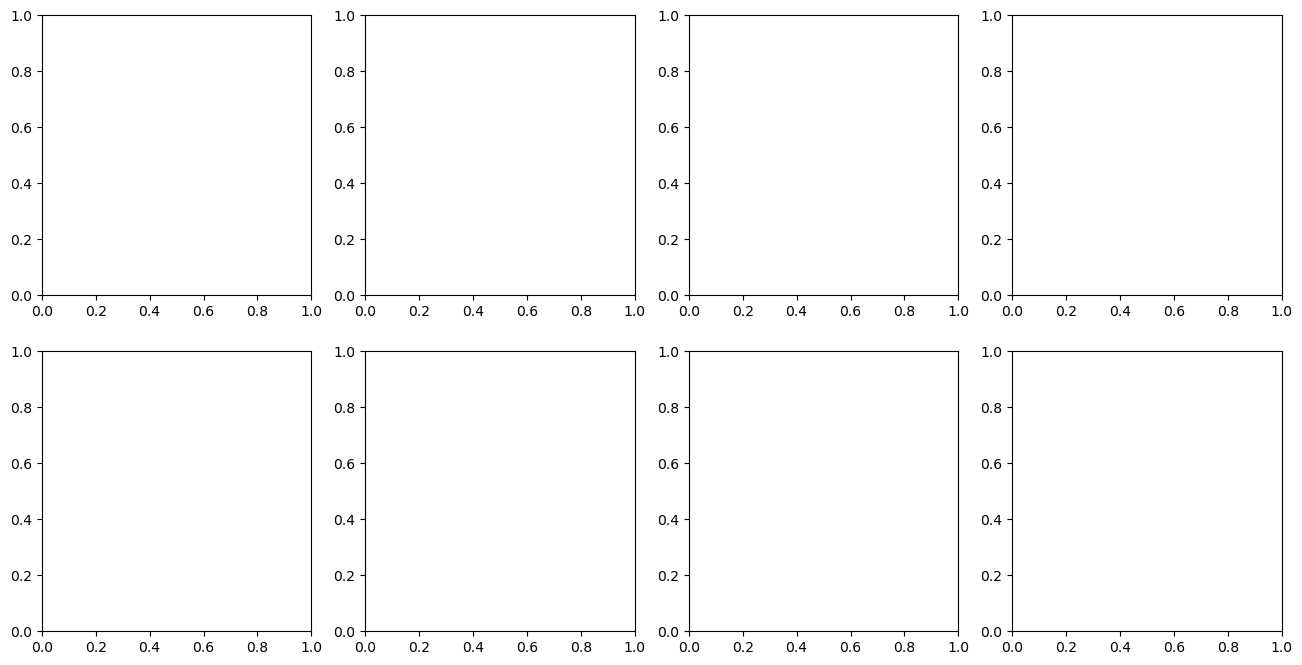

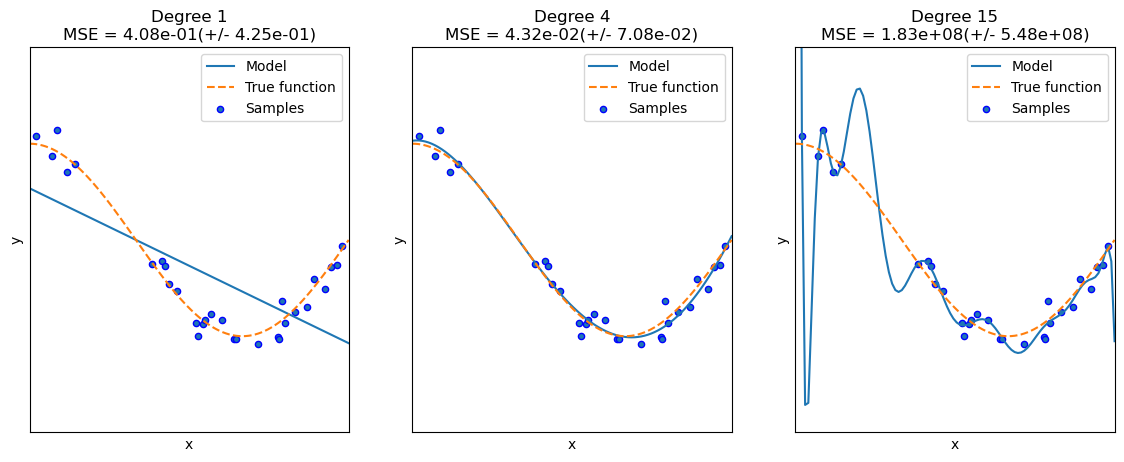

In [31]:
plt.figure(figsize=(14, 5))
degrees= [1, 4, 15]

# 다항 회귀의 차수(degree)를 1, 4, 15로 각각 변화시키면서 비교합니다.
for i in range(len(degrees)):
    ax= plt.subplot(1, len(degrees), i + 1)
    plt.setp(ax, xticks=(), yticks=())
    
    # 개별 degree별로 Polynomial 변환합니다.
    polynomial_features= PolynomialFeatures(degree=degrees[i], include_bias=False)
    linear_regression= LinearRegression()
    pipeline= Pipeline([("polynomial_features", polynomial_features),
                         ("linear_regression", linear_regression)])
    pipeline.fit(X.reshape(-1, 1), y)
    
    # 교차 검증으로 다항 회귀를 평가합니다.
    scores= cross_val_score(pipeline, X.reshape(-1, 1), y, scoring="neg_mean_squared_error", cv=10)
    # Pipeline을 구성하는 세부 객체를 접근하는 named_steps['객체명']을 이용해 회귀계수 추출
    coefficients= pipeline.named_steps['linear_regression'].coef_
    print('\nDegree {0} 회귀 계수는 {1} 입니다.'.format(degrees[i], np.round(coefficients, 2)))
    print('Degree {0} MSE 는 {1} 입니다.'.format(degrees[i], -1*np.mean(scores)))
          
    # 0 부터 1까지 테스트 데이터 세트를 100개로 나눠 예측을 수행합니다.
    # 테스트 데이터 세트에 회귀 예측을 수행하고 예측 곡선과 실제 곡선을 그려서 비교합니다.
    X_test= np.linspace(0, 1, 100)
    # 예측값 곡선
    plt.plot(X_test, pipeline.predict(X_test[:, np.newaxis]), label="Model")
    # 실제 값 곡선
    plt.plot(X_test, true_fun(X_test), '--', label="True function")
    plt.scatter(X, y, edgecolor='b', s=20, label="Samples")
    plt.xlabel("x"); plt.ylabel("y"); plt.xlim((0, 1)); plt.ylim((-2, 2)); plt.legend(loc="best")
    plt.title("Degree {}\nMSE = {:.2e}(+/- {:.2e})".format(degrees[i], -scores.mean(), scores.std()))
    
plt.show()

#### 편향-분산 트레이드오프
높은 편향/낮은 분산에서 과소적합되기 쉬우며 낮은 편향/ 높은 분산에서 과적합되기 쉬움